In [59]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path(".") # change to path folder with data


In [60]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

# Odpowiedzi na pytania:

- Czy wszystkie kolumny są istotne w kontekście zadania?

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |


In [61]:
print(titanic_df.isna().sum())

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare         98
Cabin       687
Embarked      2
dtype: int64


Na podstawie powyższej tabeli można stwierdzić, że kolumny takie jak **Name**, **Ticket** mogą nie być istotne w kontekście analizy przeżywalności pasażerów, ponieważ nie dostarczają bezpośrednich informacji o ich szansach na przeżycie. Kolumna **Cabin** również może być mniej istotna, ponieważ zawiera wiele brakujących wartości. Zamiast kalumny **Cabin**, można użyć kolumny typu **HasCabin**, która wskazuje, czy pasażer miał przypisaną kabinę, co może być bardziej istotne w kontekście analizy przeżywalności. Warto też dodać kolumnę **FamilySize**, która będzie sumą kolumn **SibSp** i **Parch**, co może być istotne w kontekście analizy przeżywalności pasażerów.

In [62]:
#Dodanie nowych kolumn
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch']

In [63]:
#Usuwanie kolumn, które nie są istotne
titanic_df.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,FamilySize
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,0,1
2,1,1,female,38.0,1,0,71.2833,C,1,1
3,1,3,female,26.0,0,0,7.9250,S,0,0
4,1,1,female,35.0,1,0,53.1000,S,1,1
5,0,3,male,35.0,0,0,8.0500,S,0,0


---

- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)

In [64]:
print(titanic_df.isna().sum())

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare           98
Embarked        2
HasCabin        0
FamilySize      0
dtype: int64


Kolumny **Age** i **Fare** można uzupełnić medianą, natomiast kolumnę **Embarked** można uzupełnić najczęściej występującą wartością (modą).

In [65]:
# Uzupełnianie brakujących wartości
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

In [66]:
print(titanic_df.isna().sum())

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
HasCabin      0
FamilySize    0
dtype: int64


---

- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)

In [67]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    str    
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    str    
 8   HasCabin    891 non-null    int64  
 9   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 69.7 KB


Nie wszystkie typy danych są odpowiednie.
Kolumna **Pclass** powinna być traktowana jako kategoria, a nie liczba całkowita.
Kolumna **Sex** również powinna być traktowana jako kategoria, a nie obiekt tekstowy.
Kolumna **Age** powinna być traktowana jako liczba całkowita, a nie liczba zmiennoprzecinkowa.
Kolumna **Embarked** powinna być traktowana jako kategoria, a nie obiekt tekstowy.

In [68]:
# Zmiana typów danych
titanic_df['Pclass'] = titanic_df['Pclass'].astype('category')
titanic_df['Sex'] = titanic_df['Sex'].astype('category')
titanic_df['Age'] = titanic_df['Age'].astype('int')
titanic_df['Embarked'] = titanic_df['Embarked'].astype('category')

In [69]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    category
 2   Sex         891 non-null    category
 3   Age         891 non-null    int64   
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Embarked    891 non-null    category
 8   HasCabin    891 non-null    int64   
 9   FamilySize  891 non-null    int64   
dtypes: category(3), float64(1), int64(6)
memory usage: 51.5 KB


---

- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)

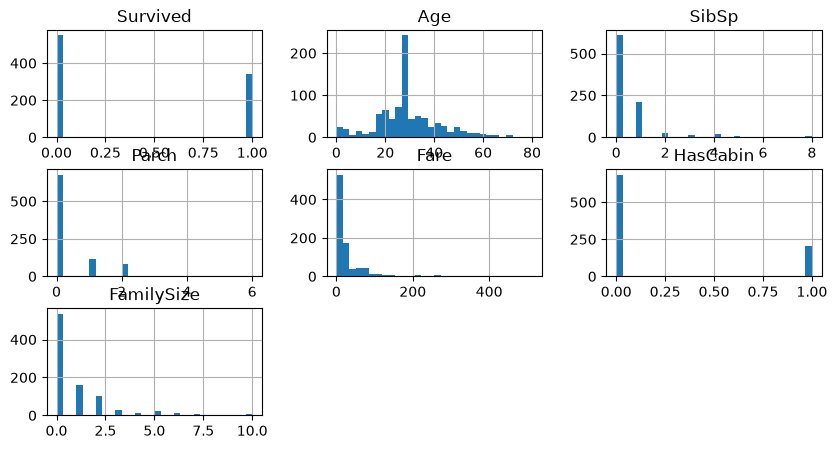

In [70]:
# Sprawdzenie dystrybucji danych dla kolumn numerycznych
titanic_df.hist(bins=30, figsize=(10, 5))
plt.show()


Dystrybucje danych dla kolumn numerycznych są asymetryczne. Kolumna **Age** ma rozkład prawoskośny, natomiast kolumna **Fare** ma rozkład lewoskośny z dużą liczbą wartości odstających.

---

- Która zmienna oznacza predykowaną klasę?

Jest to kolumna **Survived**, która wskazuje, czy pasażer przeżył (1) czy nie (0).

---

- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)

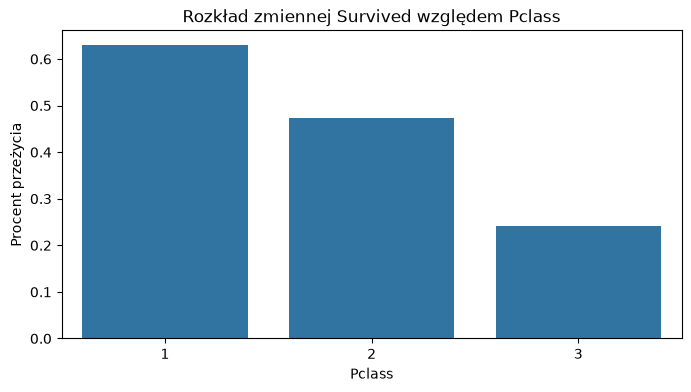

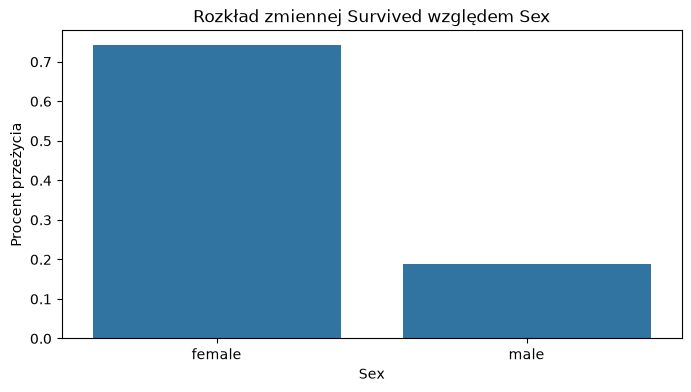

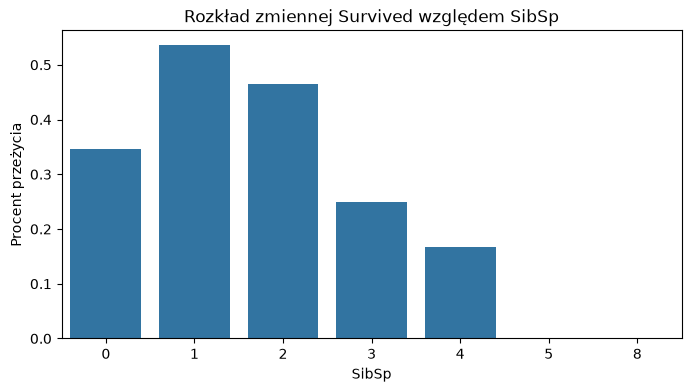

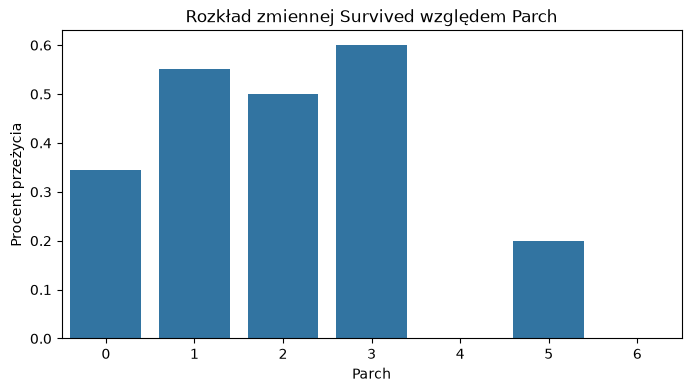

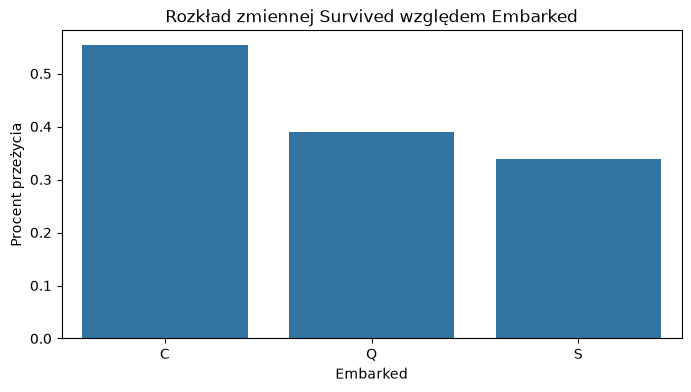

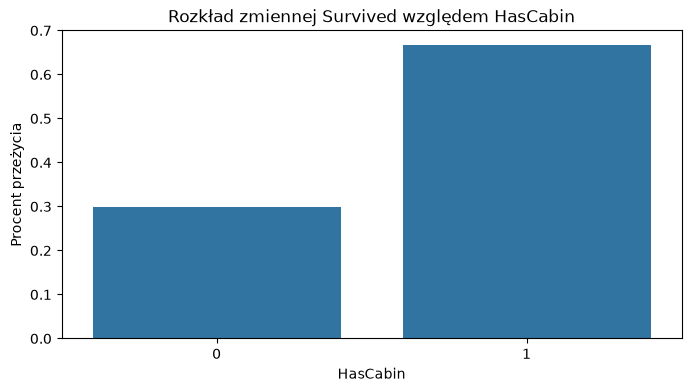

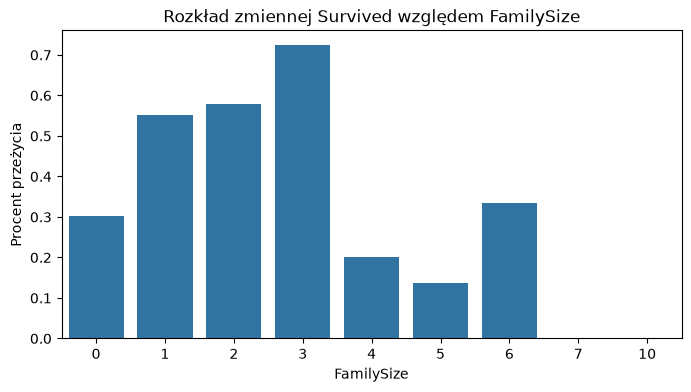

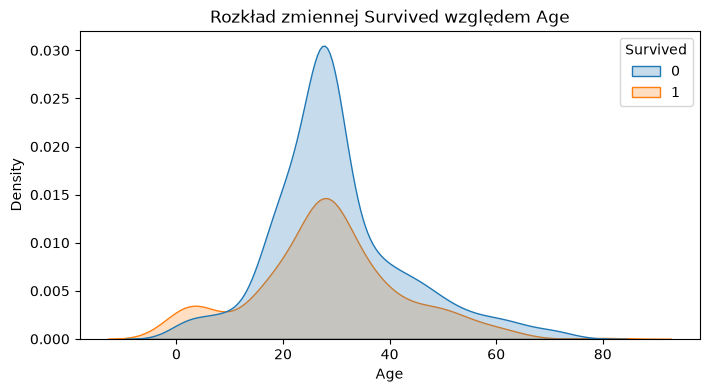

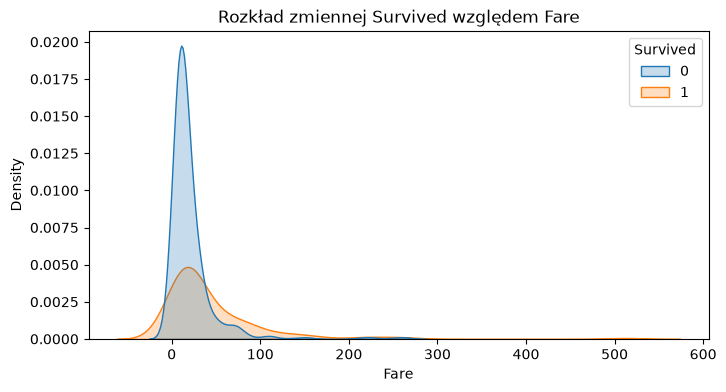

In [71]:
# Wykresy rozkładu zmiennej predykowanej względem zmiennych kategorialnych i numerycznych z procentową szansą przeżycia
cat = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'HasCabin', 'FamilySize']
num = ['Age', 'Fare']

for col in cat:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=col, y='Survived', data=titanic_df, errorbar=None)
    plt.title(f'Rozkład zmiennej Survived względem {col}')
    plt.ylabel('Procent przeżycia')
    plt.show()

for col in num:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=titanic_df, x=col, hue='Survived', fill=True)
    plt.title(f'Rozkład zmiennej Survived względem {col}')
    plt.show()

Rozkład zmiennej predykowanej **Survived** względem zmiennych kategorialnych i numerycznych pokazuje, że istnieją różnice w szansach przeżycia w zależności od klasy podróży, płci, liczby rodzeństwa i małżonków na pokładzie, liczby rodziców i dzieci na pokładzie, portu wsiadania, posiadania kabiny oraz wielkości rodziny. W przypadku zmiennych numerycznych, takich jak wiek i cena biletu, można zauważyć różnice w rozkładach między pasażerami, którzy przeżyli a tymi, którzy nie przeżyli.

---

- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Tak, końcowe rozkłady zawierają wartości skrajne (outliery), zwłaszcza w przypadku kolumn numerycznych, takich jak **Age** i **Fare**. Wartości te mogą wpływać na wyniki analizy i modelowania, dlatego warto je zidentyfikować i ewentualnie usunąć lub przekształcić.

---

- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych

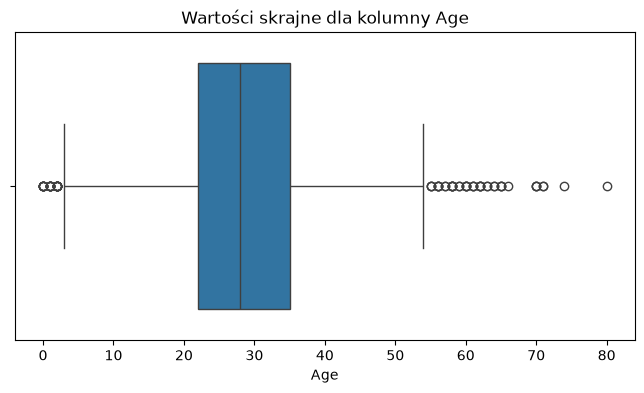

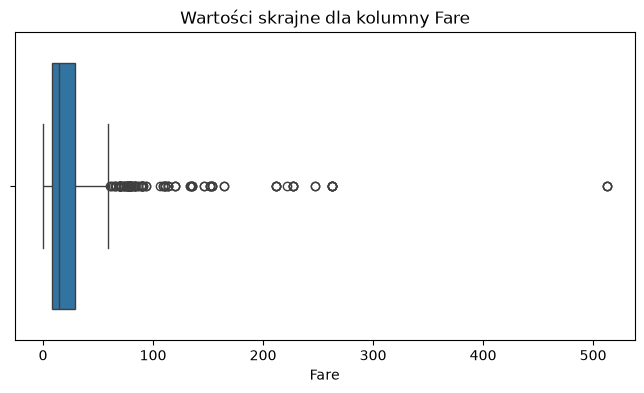

In [75]:
# Zbadanie wartości skrajnych dla kolumn numerycznych za pomocą wykresu pudełkowego (boxplot)
for col in num:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, data=titanic_df)
    plt.title(f'Wartości skrajne dla kolumny {col}')
    plt.show()